In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [5]:
def BBM2(N, U = 0.5, V = 0.5):
    h = 1. / ( N - 1 )
    
    t0 = 5
    dt = 5e-4
    T = t0 + 1
    
    beg_D = ( ( abs( U ) + abs( V ) ) ** 2 ) * dt / 4
    end_D = ( h ** 2 ) / ( 4 * dt )
    
    if beg_D > end_D:
        return None
    D = random.random() * ( beg_D - end_D ) + beg_D
    
    print(f'N - {N}')
    print(f'T - {T}')
    print(f'D - {np.round(D, 2)}')
    print('-----------------------------------------')

    mesh = np.empty((T, N, N))

    #Граничные условия
    mesh[0, :, :] = [ [ np.sin(2 * np.pi * ( x + y ) ) for x in np.linspace(0, 1, N)] for y in np.linspace(0, 1, N) ] 

    for n in range(T - 1):
        for i in range(1, N - 1):
            for j in range(1, N - 1):
                mesh[n + 1, i, j] = mesh[n, i, j] + dt * ( D * ( ( mesh[n, i + 1, j] - 2 * mesh[n, i, j] + mesh[n, i - 1, j] ) / ( h ** 2 ) +
                                                                 ( mesh[n, i, j + 1] - 2 * mesh[n, i, j] + mesh[n, i, j - 1] ) / ( h ** 2 )
                                                               ) 
                                                          - U * ( mesh[n, i + 1, j] - mesh[n, i - 1, j] ) / ( 2 * h )
                                                          - V * ( mesh[n, i, j + 1] - mesh[n, i, j + 1] ) / ( 2 * h )
                )
            #Приравнимание частн.производной на границе к 0
            mesh[n + 1, i, 0] = mesh[n + 1, i, 1]
            mesh[n + 1, i, N - 1] = mesh[n + 1, i, N - 2]
        mesh[n + 1, N - 1, :] = mesh[n + 1, N - 2, :]
        mesh[n + 1, 0, :] = mesh[n + 1, 1, :]

    fig, axs = plt.subplots(1, 2, figsize=( 10, 5 ))
    plt.suptitle(f'N = {N}')
    
    axs[0].imshow(mesh[t0, :, :])
    axs[0].set_title("Приближение")
    
    def fun_real(t, x, y):
        return ( np.e ** ( -D * t * (2 * np.pi ) ** 2 ) ) * np.sin( 2 * np.pi * (x + y - ( U + V ) * t ) )

    fun_real_mesh = np.array( [ [ [ fun_real( t, x, y ) for y in np.linspace(0, 1, N)] for x in np.linspace(0, 1, N) ] for t in np.arange(T) * dt ] )
    axs[1].imshow(fun_real_mesh[t0, :, :])
    axs[1].set_title("Реальная")
    plt.show() 
    
    def err(mesh):
        return np.std( mesh[t0, :, :] - fun_real_mesh[t0, :, :] )
        
    return err(mesh)

N - 11
T - 6
D - -2.52
-----------------------------------------


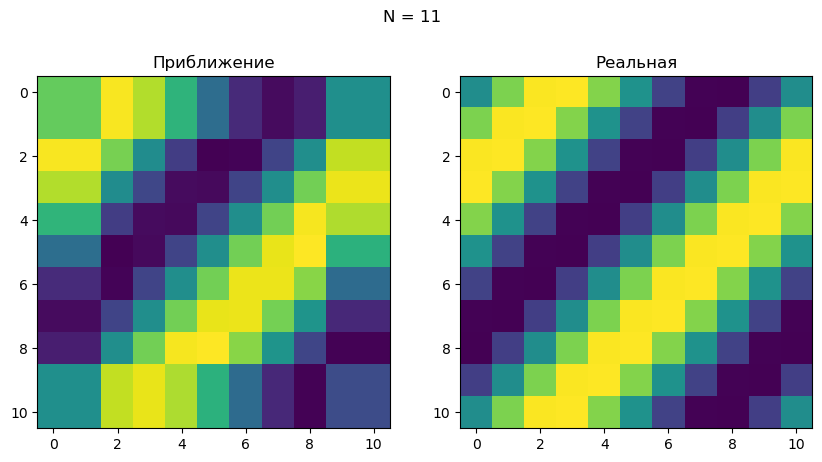

N - 21
T - 6
D - -0.58
-----------------------------------------


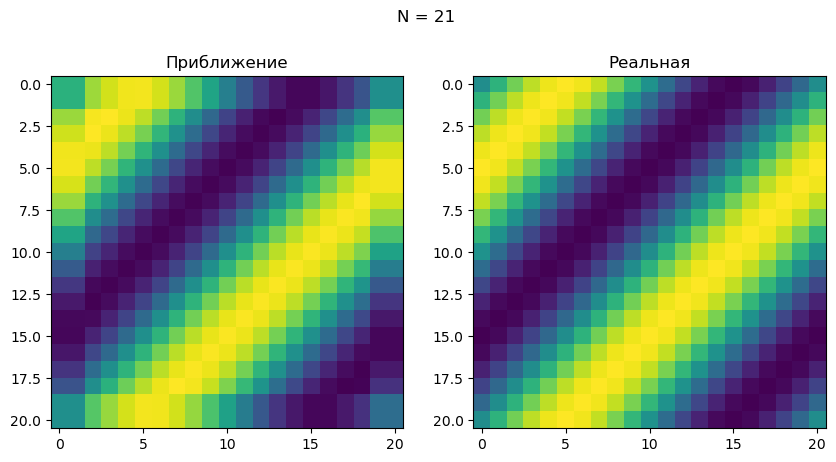

N - 41
T - 6
D - -0.04
-----------------------------------------


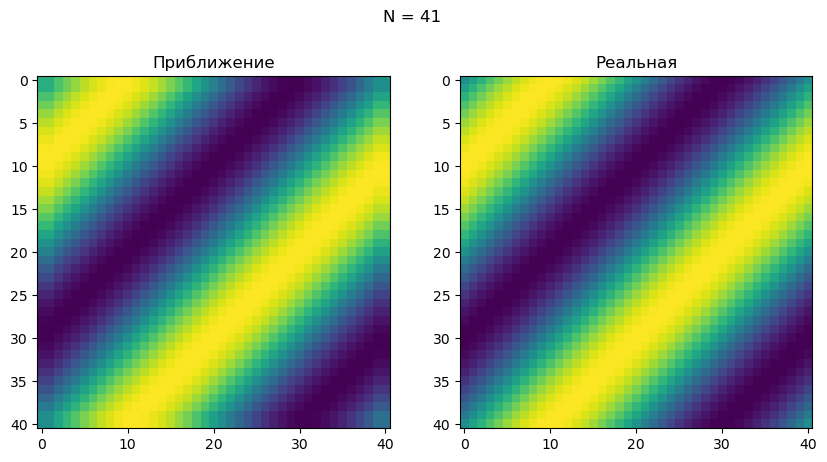

N - 81
T - 6
D - -0.06
-----------------------------------------


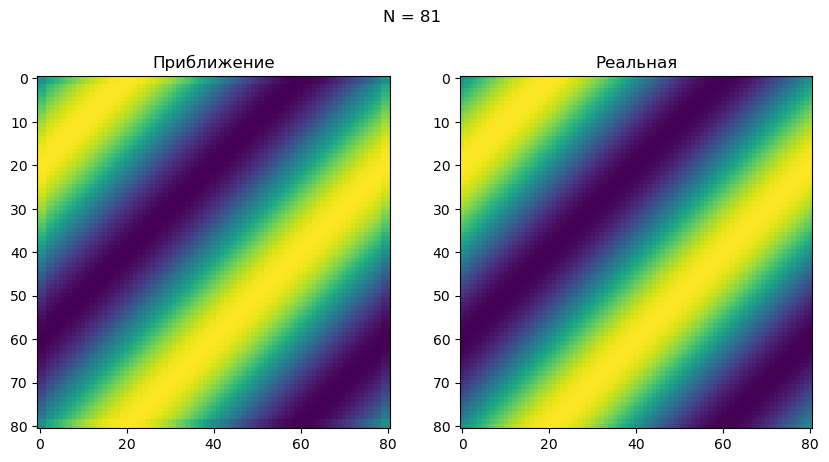

N - 161
T - 6
D - -0.01
-----------------------------------------


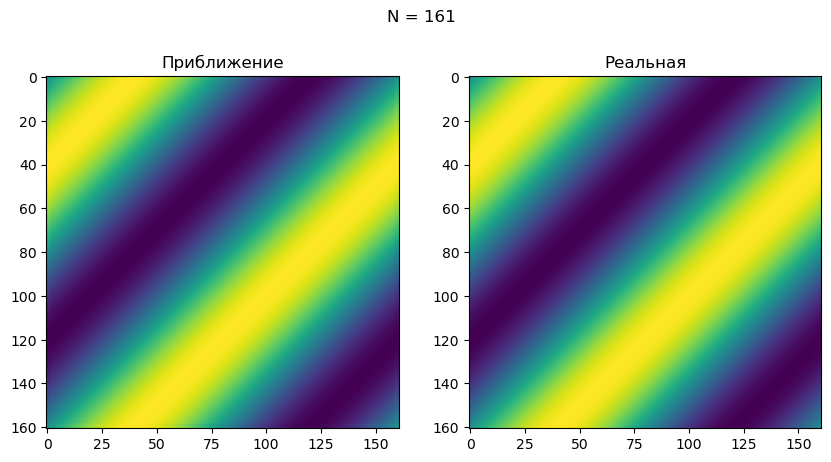

N - 321
T - 6
D - -0.0
-----------------------------------------


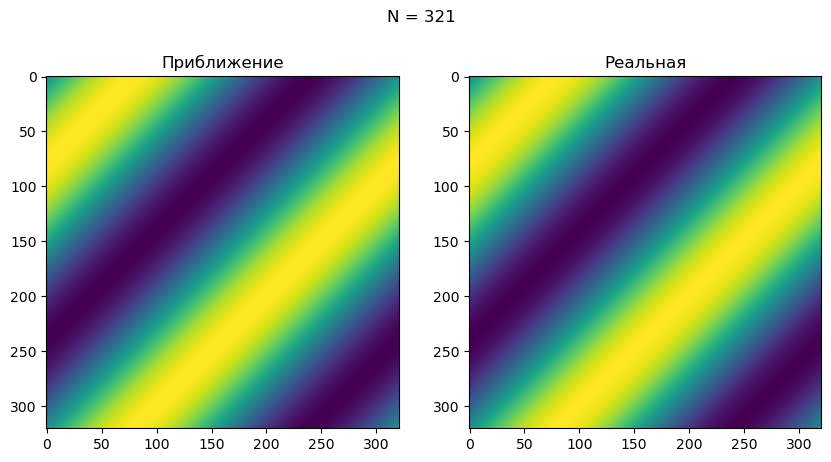

In [6]:
N_list = [ 11, 21, 41, 81, 161, 321 ]
err_list = list( map( BBM2, N_list ) )

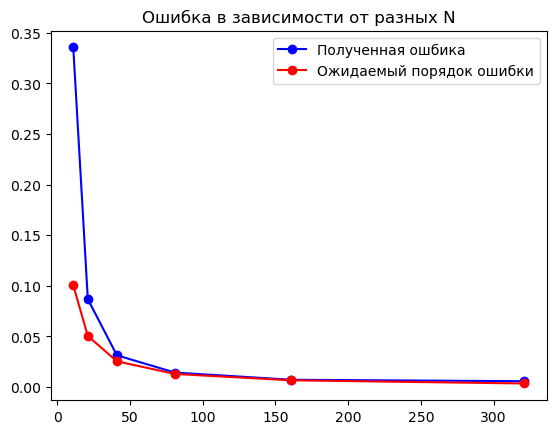

In [12]:
plt.plot( N_list, err_list, 'bo-')
plt.plot( N_list, list(map(lambda N: 1. / ( N - 1 ) + 5e-4, N_list)), 'ro-')
plt.legend(["Полученная ошбика", "Ожидаемый порядок ошибки"])
plt.title("Ошибка в зависимости от разных N")
plt.show()